In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df = pd.read_csv('/content/Online Retail.csv')

In [31]:
df.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [32]:
df["InvoiceDate"].head()

,InvoiceDate
0,01-12-2010 08:26
1,01-12-2010 08:26
2,01-12-2010 08:26
3,01-12-2010 08:26
4,01-12-2010 08:26


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [34]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


Converting invoiceDate format into datetime

In [35]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors='coerce')

In [36]:
df["InvoiceDate"].head()

,InvoiceDate
0,2010-01-12 08:26:00
1,2010-01-12 08:26:00
2,2010-01-12 08:26:00
3,2010-01-12 08:26:00
4,2010-01-12 08:26:00


Adding Revenue Column For Easy Calculation

In [37]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  232959 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
 8   Revenue      541909 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 37.2+ MB


In [39]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,308950
UnitPrice,0
CustomerID,135080
Country,0
Revenue,0


In [40]:
df.duplicated().sum()

np.int64(5269)

Remove Returns Negetive Quantities

In [41]:
df=df[df["Quantity"]> 0]

Monthly Revenue by visualization

In [42]:
monthly_sales = df.groupby(df["InvoiceDate"].dt.to_period("M"))["Revenue"].sum()



In [43]:
monthly_sales

,Revenue
InvoiceDate,
2010-01,58960.79
2010-02,47748.38
2010-03,46943.71
2010-05,31774.95
2010-06,54830.46
2010-07,99618.20
2010-08,45389.98
2010-09,53586.18
2010-10,59182.92


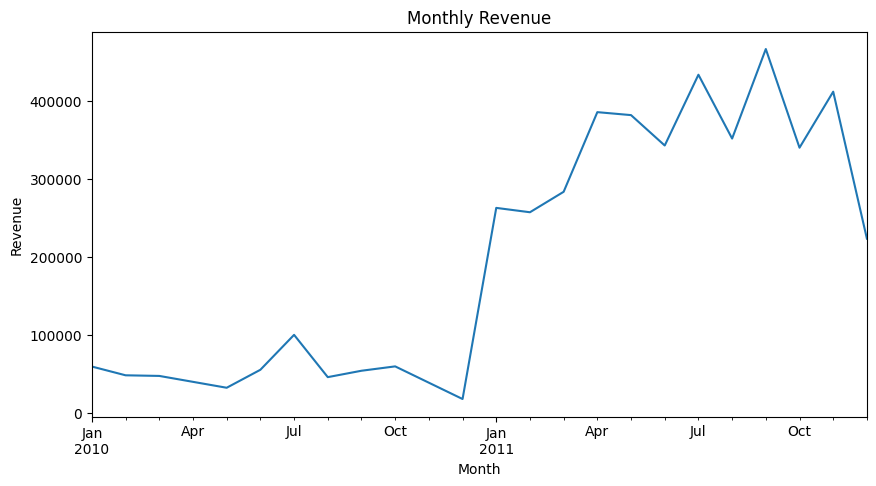

In [44]:
monthly_sales.plot(figsize = (10, 5))

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

Top Countries In Revenue

In [50]:
Country_Sale = df.groupby("Country")["Revenue"].sum().sort_values(ascending = False).head(10)



In [51]:
Country_Sale.head()

,Revenue
Country,
United Kingdom,9003097.964
Netherlands,285446.340
EIRE,283453.960
Germany,228867.140
France,209715.110


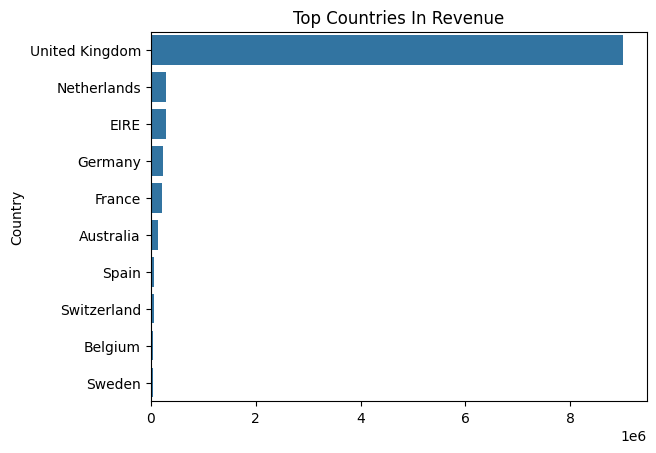

In [52]:
sns.barplot(x=Country_Sale.values, y=Country_Sale.index)
plt.title("Top Countries In Revenue")
plt.show()

Top 10 Products

In [57]:
top_products = df.groupby("Description")["Revenue"].sum().sort_values(ascending = False).head(10)

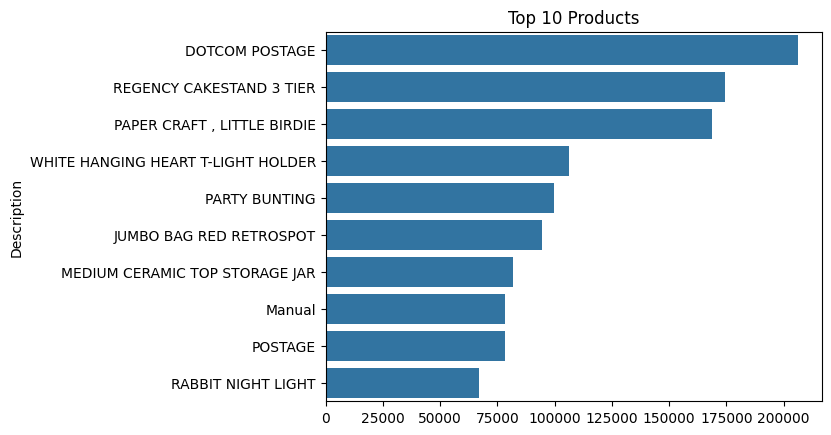

In [58]:
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Products")
plt.show()

In [59]:
df.to_csv("Retail Cleaned.csv", index= False)